In [1]:
import pickle
import os
from pathlib import Path
from collections import defaultdict

# Define paths for phase2
base_path = Path('C:/Users/ihagv/Desktop/masters_project/project_code/cluster/phase_1_2_data/phase2')
distnet_metadata_path = base_path / 'distnet' / 'metadata'
tabpfn_metadata_path = base_path / 'tabpfn' / 'metadata'

def nested_dict():
    """Helper function to create nested defaultdicts"""
    return defaultdict(nested_dict)

# Initialize dictionaries
distnet_phase2_dict = nested_dict()
tabpfn_phase2_dict = nested_dict()

# Process distnet files
print("Processing distnet phase2 metadata files...")
distnet_count = 0
for pkl_file in distnet_metadata_path.glob('*.pkl'):
    # Parse filename: distnet_scenario_fold_seed_context_seed_features_feature_drop_rate_context_size_...
    parts = pkl_file.stem.split('_')
    
    # Extract scenario (can be multi-part like clasp_factoring, spear_qcp, etc.)
    # Find where the fold number is (should be a digit)
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'distnet'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    seed_features = parts[fold_idx + 2]
    feature_drop_rate = parts[fold_idx + 3]
    context_size = parts[fold_idx + 4]
    
    # Load the pickle file
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    # Extract nllh from the metrics
    nllh = data['metrics']['nllh']
    
    # Store in nested dictionary: [scenario][fold][context_size][feature_drop_rate][seed_features][seed_context]
    distnet_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features][seed_context] = nllh
    distnet_count += 1
    
print(f"Loaded {distnet_count} distnet phase2 files")

# Process tabpfn files
print("Processing tabpfn phase2 metadata files...")
tabpfn_count = 0
for pkl_file in tabpfn_metadata_path.glob('*.pkl'):
    # Parse filename: tabpfn_scenario_fold_seed_context_seed_features_feature_drop_rate_context_size_...
    parts = pkl_file.stem.split('_')
    
    # Extract scenario (can be multi-part)
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'tabpfn'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    seed_features = parts[fold_idx + 2]
    feature_drop_rate = parts[fold_idx + 3]
    context_size = parts[fold_idx + 4]
    
    # Load the pickle file
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    # Extract nllh from the metrics
    nllh = data['metrics']['nllh']
    
    # Store in nested dictionary: [scenario][fold][context_size][feature_drop_rate][seed_features][seed_context]
    tabpfn_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features][seed_context] = nllh
    tabpfn_count += 1

print(f"Loaded {tabpfn_count} tabpfn phase2 files")

# Convert defaultdicts to regular dicts for cleaner output
def convert_to_dict(d):
    if isinstance(d, defaultdict):
        d = {k: convert_to_dict(v) for k, v in d.items()}
    return d

distnet_phase2_dict = convert_to_dict(distnet_phase2_dict)
tabpfn_phase2_dict = convert_to_dict(tabpfn_phase2_dict)

# Test access
print("\n=== Testing dictionary access ===")
print("Available scenarios in distnet_phase2:", list(distnet_phase2_dict.keys()))
print("Available scenarios in tabpfn_phase2:", list(tabpfn_phase2_dict.keys()))

# Example access for distnet
if 'clasp_factoring' in distnet_phase2_dict:
    scenario = 'clasp_factoring'
    if '0' in distnet_phase2_dict[scenario]:
        fold = '0'
        available_context_sizes = list(distnet_phase2_dict[scenario][fold].keys())
        if available_context_sizes:
            context_size = available_context_sizes[0]
            available_drop_rates = list(distnet_phase2_dict[scenario][fold][context_size].keys())
            if available_drop_rates:
                feature_drop_rate = available_drop_rates[0]
                available_seed_features = list(distnet_phase2_dict[scenario][fold][context_size][feature_drop_rate].keys())
                if available_seed_features:
                    seed_features = available_seed_features[0]
                    available_seed_contexts = list(distnet_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features].keys())
                    if available_seed_contexts:
                        seed_context = available_seed_contexts[0]
                        nllh_value = distnet_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features][seed_context]
                        print(f"\nExample: distnet_phase2_dict['{scenario}']['{fold}']['{context_size}']['{feature_drop_rate}']['{seed_features}']['{seed_context}'] = {nllh_value}")

# Example access for tabpfn
if 'clasp_factoring' in tabpfn_phase2_dict:
    scenario = 'clasp_factoring'
    if '0' in tabpfn_phase2_dict[scenario]:
        fold = '0'
        available_context_sizes = list(tabpfn_phase2_dict[scenario][fold].keys())
        if available_context_sizes:
            context_size = available_context_sizes[0]
            available_drop_rates = list(tabpfn_phase2_dict[scenario][fold][context_size].keys())
            if available_drop_rates:
                feature_drop_rate = available_drop_rates[0]
                available_seed_features = list(tabpfn_phase2_dict[scenario][fold][context_size][feature_drop_rate].keys())
                if available_seed_features:
                    seed_features = available_seed_features[0]
                    available_seed_contexts = list(tabpfn_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features].keys())
                    if available_seed_contexts:
                        seed_context = available_seed_contexts[0]
                        nllh_value = tabpfn_phase2_dict[scenario][fold][context_size][feature_drop_rate][seed_features][seed_context]
                        print(f"Example: tabpfn_phase2_dict['{scenario}']['{fold}']['{context_size}']['{feature_drop_rate}']['{seed_features}']['{seed_context}'] = {nllh_value}")

print("\n=== Dictionaries created successfully! ===")
print(f"distnet_phase2_dict has {len(distnet_phase2_dict)} scenarios")
print(f"tabpfn_phase2_dict has {len(tabpfn_phase2_dict)} scenarios")

Processing distnet phase2 metadata files...
Loaded 2520 distnet phase2 files
Processing tabpfn phase2 metadata files...
Loaded 2520 tabpfn phase2 files

=== Testing dictionary access ===
Available scenarios in distnet_phase2: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']
Available scenarios in tabpfn_phase2: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']

Example: distnet_phase2_dict['clasp_factoring']['0']['8192']['0.2']['1000']['100'] = -0.19334248793206324
Example: tabpfn_phase2_dict['clasp_factoring']['0']['8192']['0.2']['1000']['100'] = -0.2254221534729004

=== Dictionaries created successfully! ===
distnet_phase2_dict has 7 scenarios
tabpfn_phase2_dict has 7 scenarios


In [2]:
# Define expected configurations for phase2
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

FOLDS = range(10)
CONTEXT_SEEDS = [100, 200, 300]
FEATURE_SEEDS = [1000, 2000, 3000]
FEATURE_DROP_RATES = [0.2, 0.4, 0.6, 0.8]

# Note: Phase2 experiments use context_size=8192 for all configurations
CONTEXT_SIZE = '8192'

# Convert to strings for comparison (since dict keys are strings)
FOLDS_STR = [str(f) for f in FOLDS]
CONTEXT_SEEDS_STR = [str(cs) for cs in CONTEXT_SEEDS]
FEATURE_SEEDS_STR = [str(fs) for fs in FEATURE_SEEDS]
FEATURE_DROP_RATES_STR = [str(fdr) for fdr in FEATURE_DROP_RATES]

# Total expected configurations per model
total_expected = len(SCENARIOS) * len(FOLDS) * len(CONTEXT_SEEDS) * len(FEATURE_SEEDS) * len(FEATURE_DROP_RATES)
print(f"Expected total configurations per model: {total_expected}")
print(f"  = {len(SCENARIOS)} scenarios × {len(FOLDS)} folds × {len(CONTEXT_SEEDS)} context seeds × {len(FEATURE_SEEDS)} feature seeds × {len(FEATURE_DROP_RATES)} drop rates")

# Check distnet_phase2 missing configurations
print("\n" + "="*80)
print("CHECKING DISTNET PHASE2 CONFIGURATIONS")
print("="*80)

distnet_phase2_missing = []
distnet_phase2_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for seed_context in CONTEXT_SEEDS_STR:
            for seed_features in FEATURE_SEEDS_STR:
                for feature_drop_rate in FEATURE_DROP_RATES_STR:
                    try:
                        _ = distnet_phase2_dict[scenario][fold][CONTEXT_SIZE][feature_drop_rate][seed_features][seed_context]
                        distnet_phase2_found += 1
                    except (KeyError, TypeError):
                        distnet_phase2_missing.append((scenario, fold, seed_context, seed_features, feature_drop_rate))

print(f"\nDistNet Phase2: Found {distnet_phase2_found}/{total_expected} configurations")
print(f"Missing: {len(distnet_phase2_missing)} configurations")

if distnet_phase2_missing:
    print("\n--- Missing DistNet Phase2 Configurations ---")
    # Group by scenario for better readability
    from collections import defaultdict
    missing_by_scenario = defaultdict(list)
    for scenario, fold, seed_context, seed_features, feature_drop_rate in distnet_phase2_missing:
        missing_by_scenario[scenario].append((fold, seed_context, seed_features, feature_drop_rate))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 30:  # Show details if not too many
                for fold, seed_context, seed_features, feature_drop_rate in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, seed_context={seed_context}, seed_features={seed_features}, feature_drop_rate={feature_drop_rate}")

# Check tabpfn_phase2 missing configurations
print("\n" + "="*80)
print("CHECKING TABPFN PHASE2 CONFIGURATIONS")
print("="*80)

tabpfn_phase2_missing = []
tabpfn_phase2_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for seed_context in CONTEXT_SEEDS_STR:
            for seed_features in FEATURE_SEEDS_STR:
                for feature_drop_rate in FEATURE_DROP_RATES_STR:
                    try:
                        _ = tabpfn_phase2_dict[scenario][fold][CONTEXT_SIZE][feature_drop_rate][seed_features][seed_context]
                        tabpfn_phase2_found += 1
                    except (KeyError, TypeError):
                        tabpfn_phase2_missing.append((scenario, fold, seed_context, seed_features, feature_drop_rate))

print(f"\nTabPFN Phase2: Found {tabpfn_phase2_found}/{total_expected} configurations")
print(f"Missing: {len(tabpfn_phase2_missing)} configurations")

if tabpfn_phase2_missing:
    print("\n--- Missing TabPFN Phase2 Configurations ---")
    # Group by scenario for better readability
    missing_by_scenario = defaultdict(list)
    for scenario, fold, seed_context, seed_features, feature_drop_rate in tabpfn_phase2_missing:
        missing_by_scenario[scenario].append((fold, seed_context, seed_features, feature_drop_rate))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 30:  # Show details if not too many
                for fold, seed_context, seed_features, feature_drop_rate in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, seed_context={seed_context}, seed_features={seed_features}, feature_drop_rate={feature_drop_rate}")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"DistNet Phase2:  {distnet_phase2_found}/{total_expected} ({100*distnet_phase2_found/total_expected:.1f}% complete)")
print(f"TabPFN Phase2:   {tabpfn_phase2_found}/{total_expected} ({100*tabpfn_phase2_found/total_expected:.1f}% complete)")

# Print missing configurations in requested format
print("\n" + "="*80)
print("MISSING CONFIGURATIONS LIST")
print("="*80)

if distnet_phase2_missing:
    print("\n--- DistNet Phase2 Missing (format: scenario fold seed_context seed_features feature_drop_rate) ---")
    for scenario, fold, seed_context, seed_features, feature_drop_rate in distnet_phase2_missing:
        print(f"{scenario} {fold} {seed_context} {seed_features} {feature_drop_rate}")

if tabpfn_phase2_missing:
    print("\n--- TabPFN Phase2 Missing (format: scenario fold seed_context seed_features feature_drop_rate) ---")
    for scenario, fold, seed_context, seed_features, feature_drop_rate in tabpfn_phase2_missing:
        print(f"{scenario} {fold} {seed_context} {seed_features} {feature_drop_rate}")

Expected total configurations per model: 2520
  = 7 scenarios × 10 folds × 3 context seeds × 3 feature seeds × 4 drop rates

CHECKING DISTNET PHASE2 CONFIGURATIONS

DistNet Phase2: Found 2520/2520 configurations
Missing: 0 configurations

CHECKING TABPFN PHASE2 CONFIGURATIONS

TabPFN Phase2: Found 2520/2520 configurations
Missing: 0 configurations

SUMMARY
DistNet Phase2:  2520/2520 (100.0% complete)
TabPFN Phase2:   2520/2520 (100.0% complete)

MISSING CONFIGURATIONS LIST


In [2]:
# Define expected configurations for phase2
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

FOLDS = range(10)
CONTEXT_SEEDS = [100, 200, 300]
FEATURE_SEEDS = [1000, 2000, 3000]
FEATURE_DROP_RATES = [0.2, 0.4, 0.6, 0.8]

# Note: Phase2 experiments use context_size=8192 for all configurations
CONTEXT_SIZE = '8192'

# Convert to strings for comparison (since dict keys are strings)
FOLDS_STR = [str(f) for f in FOLDS]
CONTEXT_SEEDS_STR = [str(cs) for cs in CONTEXT_SEEDS]
FEATURE_SEEDS_STR = [str(fs) for fs in FEATURE_SEEDS]
FEATURE_DROP_RATES_STR = [str(fdr) for fdr in FEATURE_DROP_RATES]

# Total expected configurations per model
total_expected = len(SCENARIOS) * len(FOLDS) * len(CONTEXT_SEEDS) * len(FEATURE_SEEDS) * len(FEATURE_DROP_RATES)
print(f"Expected total configurations per model: {total_expected}")
print(f"  = {len(SCENARIOS)} scenarios × {len(FOLDS)} folds × {len(CONTEXT_SEEDS)} context seeds × {len(FEATURE_SEEDS)} feature seeds × {len(FEATURE_DROP_RATES)} drop rates")

# Check distnet_phase2 missing configurations
print("\n" + "="*80)
print("CHECKING DISTNET PHASE2 CONFIGURATIONS")
print("="*80)

distnet_phase2_missing = []
distnet_phase2_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for seed_context in CONTEXT_SEEDS_STR:
            for seed_features in FEATURE_SEEDS_STR:
                for feature_drop_rate in FEATURE_DROP_RATES_STR:
                    try:
                        _ = distnet_phase2_dict[scenario][fold][CONTEXT_SIZE][feature_drop_rate][seed_features][seed_context]
                        distnet_phase2_found += 1
                    except (KeyError, TypeError):
                        distnet_phase2_missing.append((scenario, fold, seed_context, seed_features, feature_drop_rate))

print(f"\nDistNet Phase2: Found {distnet_phase2_found}/{total_expected} configurations")
print(f"Missing: {len(distnet_phase2_missing)} configurations")

if distnet_phase2_missing:
    print("\n--- Missing DistNet Phase2 Configurations ---")
    # Group by scenario for better readability
    from collections import defaultdict
    missing_by_scenario = defaultdict(list)
    for scenario, fold, seed_context, seed_features, feature_drop_rate in distnet_phase2_missing:
        missing_by_scenario[scenario].append((fold, seed_context, seed_features, feature_drop_rate))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 30:  # Show details if not too many
                for fold, seed_context, seed_features, feature_drop_rate in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, seed_context={seed_context}, seed_features={seed_features}, feature_drop_rate={feature_drop_rate}")

# Check tabpfn_phase2 missing configurations
print("\n" + "="*80)
print("CHECKING TABPFN PHASE2 CONFIGURATIONS")
print("="*80)

tabpfn_phase2_missing = []
tabpfn_phase2_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for seed_context in CONTEXT_SEEDS_STR:
            for seed_features in FEATURE_SEEDS_STR:
                for feature_drop_rate in FEATURE_DROP_RATES_STR:
                    try:
                        _ = tabpfn_phase2_dict[scenario][fold][CONTEXT_SIZE][feature_drop_rate][seed_features][seed_context]
                        tabpfn_phase2_found += 1
                    except (KeyError, TypeError):
                        tabpfn_phase2_missing.append((scenario, fold, seed_context, seed_features, feature_drop_rate))

print(f"\nTabPFN Phase2: Found {tabpfn_phase2_found}/{total_expected} configurations")
print(f"Missing: {len(tabpfn_phase2_missing)} configurations")

if tabpfn_phase2_missing:
    print("\n--- Missing TabPFN Phase2 Configurations ---")
    # Group by scenario for better readability
    missing_by_scenario = defaultdict(list)
    for scenario, fold, seed_context, seed_features, feature_drop_rate in tabpfn_phase2_missing:
        missing_by_scenario[scenario].append((fold, seed_context, seed_features, feature_drop_rate))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 30:  # Show details if not too many
                for fold, seed_context, seed_features, feature_drop_rate in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, seed_context={seed_context}, seed_features={seed_features}, feature_drop_rate={feature_drop_rate}")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"DistNet Phase2:  {distnet_phase2_found}/{total_expected} ({100*distnet_phase2_found/total_expected:.1f}% complete)")
print(f"TabPFN Phase2:   {tabpfn_phase2_found}/{total_expected} ({100*tabpfn_phase2_found/total_expected:.1f}% complete)")

# Print missing configurations in requested format
print("\n" + "="*80)
print("MISSING CONFIGURATIONS LIST")
print("="*80)

if distnet_phase2_missing:
    print("\n--- DistNet Phase2 Missing (format: scenario fold seed_context seed_features feature_drop_rate) ---")
    for scenario, fold, seed_context, seed_features, feature_drop_rate in distnet_phase2_missing:
        print(f"{scenario} {fold} {seed_context} {seed_features} {feature_drop_rate}")

if tabpfn_phase2_missing:
    print("\n--- TabPFN Phase2 Missing (format: scenario fold seed_context seed_features feature_drop_rate) ---")
    for scenario, fold, seed_context, seed_features, feature_drop_rate in tabpfn_phase2_missing:
        print(f"{scenario} {fold} {seed_context} {seed_features} {feature_drop_rate}")

Expected total configurations per model: 2520
  = 7 scenarios × 10 folds × 3 context seeds × 3 feature seeds × 4 drop rates

CHECKING DISTNET PHASE2 CONFIGURATIONS

DistNet Phase2: Found 2520/2520 configurations
Missing: 0 configurations

CHECKING TABPFN PHASE2 CONFIGURATIONS

TabPFN Phase2: Found 2408/2520 configurations
Missing: 112 configurations

--- Missing TabPFN Phase2 Configurations ---

clasp_factoring: 24 missing
  - fold=0, seed_context=100, seed_features=3000, feature_drop_rate=0.2
  - fold=0, seed_context=300, seed_features=1000, feature_drop_rate=0.2
  - fold=1, seed_context=100, seed_features=1000, feature_drop_rate=0.8
  - fold=1, seed_context=200, seed_features=2000, feature_drop_rate=0.6
  - fold=1, seed_context=300, seed_features=3000, feature_drop_rate=0.4
  - fold=2, seed_context=200, seed_features=1000, feature_drop_rate=0.2
  - fold=2, seed_context=300, seed_features=1000, feature_drop_rate=0.8
  - fold=3, seed_context=100, seed_features=2000, feature_drop_rate=0

Loading phase1 data for feature drop rate = 0...
Phase1 data loaded successfully!


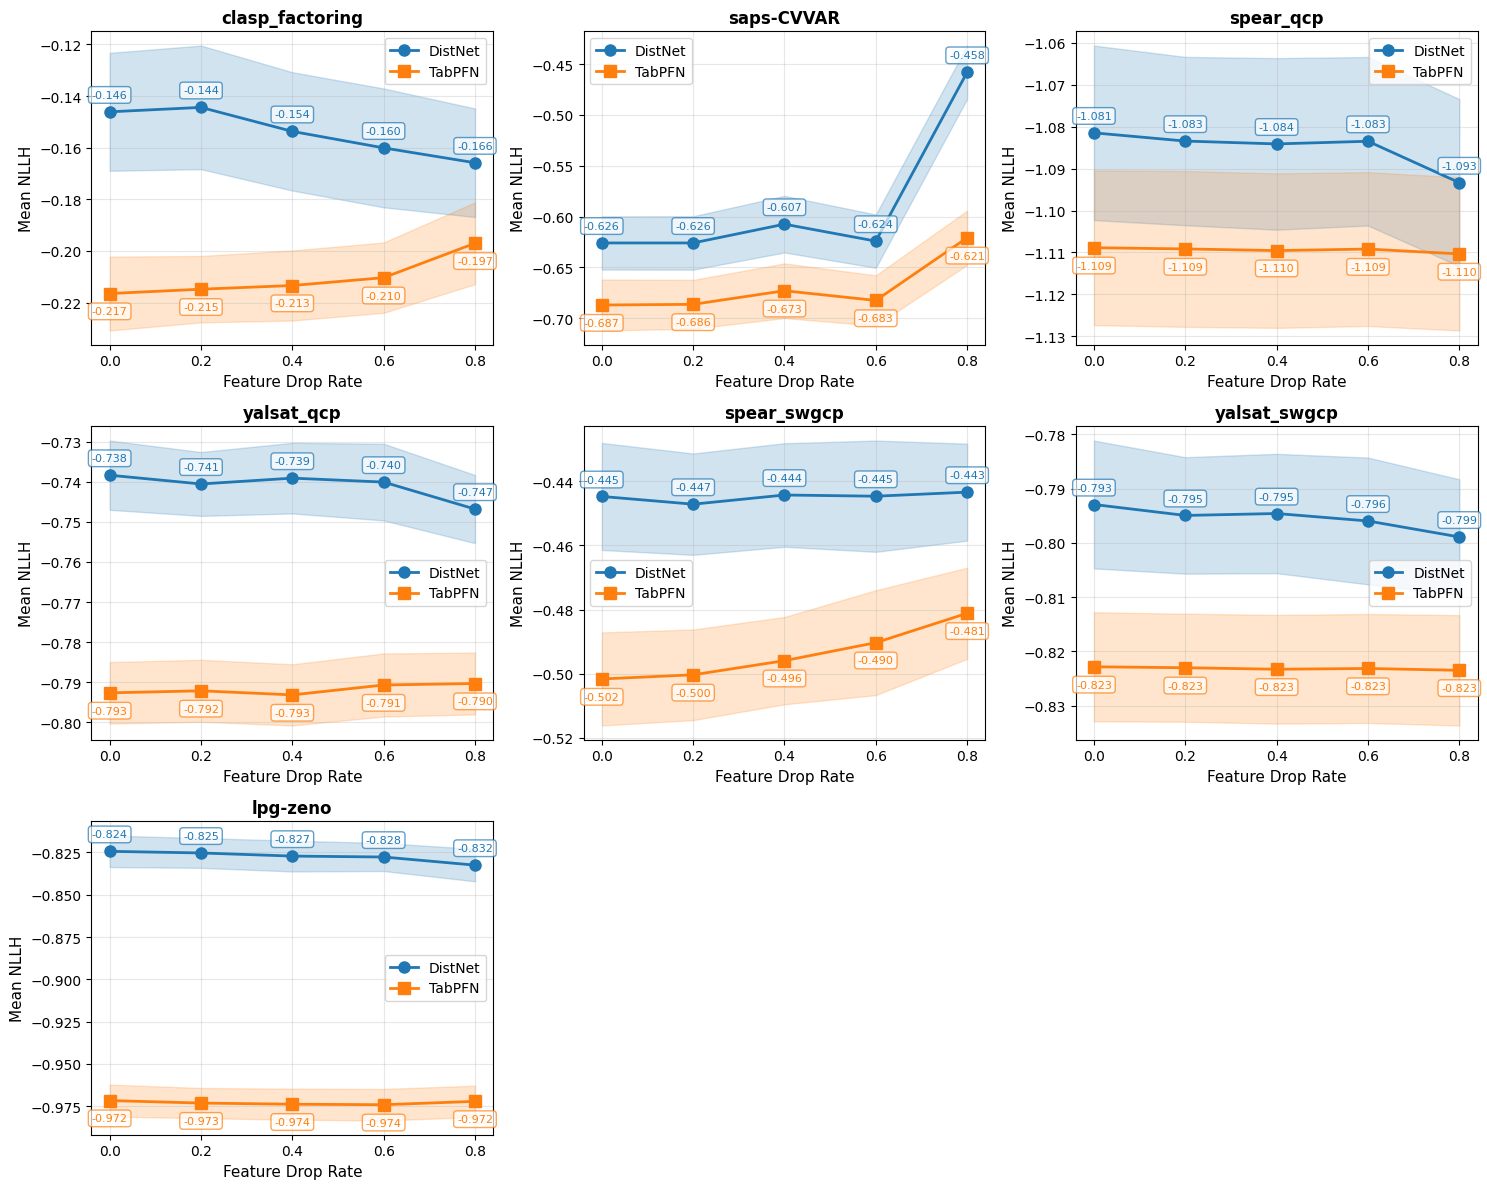


=== Plot generated successfully! ===
Saved as: phase2_feature_drop_rate_analysis.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define expected configurations for phase2
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

FOLDS = range(10)
CONTEXT_SEEDS = [100, 200, 300]
FEATURE_SEEDS = [1000, 2000, 3000]
FEATURE_DROP_RATES = [0.0, 0.2, 0.4, 0.6, 0.8]  # Added 0.0 for no feature drop

# Note: Phase2 experiments use context_size=8192 for all configurations
CONTEXT_SIZE = '8192'

# Convert to strings for comparison (since dict keys are strings)
FOLDS_STR = [str(f) for f in FOLDS]
CONTEXT_SEEDS_STR = [str(cs) for cs in CONTEXT_SEEDS]
FEATURE_SEEDS_STR = [str(fs) for fs in FEATURE_SEEDS]
FEATURE_DROP_RATES_STR = [str(fdr) for fdr in [0.2, 0.4, 0.6, 0.8]]

# Load phase1 data for drop rate = 0
print("Loading phase1 data for feature drop rate = 0...")
phase1_base_path = Path('C:/Users/ihagv/Desktop/masters_project/project_code/cluster/phase_1_2_data/phase1')
phase1_distnet_metadata = phase1_base_path / 'distnet' / 'metadata'
phase1_tabpfn_metadata = phase1_base_path / 'tabpfn' / 'metadata'

from collections import defaultdict

def nested_dict():
    return defaultdict(nested_dict)

# Initialize phase1 dictionaries
distnet_phase1_dict = nested_dict()
tabpfn_phase1_dict = nested_dict()

# Process phase1 distnet files
for pkl_file in phase1_distnet_metadata.glob('*.pkl'):
    parts = pkl_file.stem.split('_')
    
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    context_size = parts[fold_idx + 4]
    
    # Only load context_size = 8192
    if context_size == CONTEXT_SIZE:
        import pickle
        with open(pkl_file, 'rb') as f:
            data = pickle.load(f)
        nllh = data['metrics']['nllh']
        distnet_phase1_dict[scenario][fold][seed_context] = nllh

# Process phase1 tabpfn files
for pkl_file in phase1_tabpfn_metadata.glob('*.pkl'):
    parts = pkl_file.stem.split('_')
    
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    context_size = parts[fold_idx + 4]
    
    # Only load context_size = 8192
    if context_size == CONTEXT_SIZE:
        import pickle
        with open(pkl_file, 'rb') as f:
            data = pickle.load(f)
        nllh = data['metrics']['nllh']
        tabpfn_phase1_dict[scenario][fold][seed_context] = nllh

print("Phase1 data loaded successfully!")

def compute_mean_std_nllh_phase2(data_dict, scenario, feature_drop_rate):
    """
    Compute mean and std NLLH for phase2 data
    Aggregation: average context_seeds -> average feature_seeds -> compute mean and std over folds
    """
    fold_means = []
    
    for fold in FOLDS_STR:
        feature_seed_means = []
        
        for feature_seed in FEATURE_SEEDS_STR:
            context_seed_values = []
            
            for context_seed in CONTEXT_SEEDS_STR:
                try:
                    nllh = data_dict[scenario][fold][CONTEXT_SIZE][feature_drop_rate][feature_seed][context_seed]
                    context_seed_values.append(nllh)
                except (KeyError, TypeError):
                    pass
            
            if context_seed_values:
                feature_seed_means.append(np.mean(context_seed_values))
        
        if feature_seed_means:
            fold_means.append(np.mean(feature_seed_means))
    
    if fold_means:
        return np.mean(fold_means), np.std(fold_means)
    else:
        return None, None

def compute_mean_std_nllh_phase1(data_dict, scenario):
    """
    Compute mean and std NLLH for phase1 data (drop rate = 0)
    Aggregation: average context_seeds for each fold -> compute mean and std over folds
    """
    fold_means = []
    
    for fold in FOLDS_STR:
        context_seed_values = []
        
        for context_seed in CONTEXT_SEEDS_STR:
            try:
                nllh = data_dict[scenario][fold][context_seed]
                context_seed_values.append(nllh)
            except (KeyError, TypeError):
                pass
        
        if context_seed_values:
            fold_means.append(np.mean(context_seed_values))
    
    if fold_means:
        return np.mean(fold_means), np.std(fold_means)
    else:
        return None, None

# Create plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    # Compute mean and std NLLH for each feature drop rate
    distnet_means = []
    distnet_stds = []
    tabpfn_means = []
    tabpfn_stds = []
    
    # First, get drop rate = 0 from phase1
    distnet_mean_0, distnet_std_0 = compute_mean_std_nllh_phase1(distnet_phase1_dict, scenario)
    tabpfn_mean_0, tabpfn_std_0 = compute_mean_std_nllh_phase1(tabpfn_phase1_dict, scenario)
    
    distnet_means.append(distnet_mean_0)
    distnet_stds.append(distnet_std_0 if distnet_std_0 is not None else 0)
    tabpfn_means.append(tabpfn_mean_0)
    tabpfn_stds.append(tabpfn_std_0 if tabpfn_std_0 is not None else 0)
    
    # Then get drop rates 0.2, 0.4, 0.6, 0.8 from phase2
    for fdr in FEATURE_DROP_RATES_STR:
        distnet_mean, distnet_std = compute_mean_std_nllh_phase2(distnet_phase2_dict, scenario, fdr)
        tabpfn_mean, tabpfn_std = compute_mean_std_nllh_phase2(tabpfn_phase2_dict, scenario, fdr)
        
        distnet_means.append(distnet_mean)
        distnet_stds.append(distnet_std if distnet_std is not None else 0)
        tabpfn_means.append(tabpfn_mean)
        tabpfn_stds.append(tabpfn_std if tabpfn_std is not None else 0)
    
    # Convert to numpy arrays
    distnet_means = np.array(distnet_means)
    distnet_stds = np.array(distnet_stds)
    tabpfn_means = np.array(tabpfn_means)
    tabpfn_stds = np.array(tabpfn_stds)
    
    # Plot the lines with shaded std regions
    ax.plot(FEATURE_DROP_RATES, distnet_means, marker='o', linewidth=2, markersize=8, label='DistNet', color='#1f77b4')
    ax.fill_between(FEATURE_DROP_RATES, distnet_means - distnet_stds, distnet_means + distnet_stds, 
                     color='#1f77b4', alpha=0.2)
    
    ax.plot(FEATURE_DROP_RATES, tabpfn_means, marker='s', linewidth=2, markersize=8, label='TabPFN', color='#ff7f0e')
    ax.fill_between(FEATURE_DROP_RATES, tabpfn_means - tabpfn_stds, tabpfn_means + tabpfn_stds, 
                     color='#ff7f0e', alpha=0.2)
    
    # Annotate points with NLLH values
    for i, (x, y) in enumerate(zip(FEATURE_DROP_RATES, distnet_means)):
        if y is not None and not np.isnan(y):
            ax.annotate(f'{y:.3f}', 
                       xy=(x, y), 
                       xytext=(0, 10),
                       textcoords='offset points',
                       ha='center',
                       fontsize=8,
                       color='#1f77b4',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#1f77b4', alpha=0.7))
    
    for i, (x, y) in enumerate(zip(FEATURE_DROP_RATES, tabpfn_means)):
        if y is not None and not np.isnan(y):
            ax.annotate(f'{y:.3f}', 
                       xy=(x, y), 
                       xytext=(0, -15),
                       textcoords='offset points',
                       ha='center',
                       fontsize=8,
                       color='#ff7f0e',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ff7f0e', alpha=0.7))
    
    ax.set_xlabel('Feature Drop Rate', fontsize=11)
    ax.set_ylabel('Mean NLLH', fontsize=11)
    ax.set_title(f'{scenario}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(FEATURE_DROP_RATES)

# Hide extra subplots
for idx in range(len(SCENARIOS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('phase2_feature_drop_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Plot generated successfully! ===")
print("Saved as: phase2_feature_drop_rate_analysis.png")